<h1 style="text-align:center;">Song Success Prediction Model</h1>
<h2 style="text-align:center;">EDA</h2>

<h4 style="text-align:center;">by Cameron Hicks</h3>

# Introduction

The purpose of this notebook is to explore and understand the dataset prepared for the Song Success Prediction model in the Data Wrangling notebook. This data is a combination of the Spotify Analytics Dataset and supplemental country data. In the following steps we will identify potential target features for modeling, explore each feature and it's relationship to the target feature, and explore overall correlation of the dataset. 

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import requests
import time
from urllib.parse import quote
from sklearn.preprocessing import MultiLabelBinarizer
from scipy.stats import chi2_contingency
from scipy.stats import pointbiserialr

# Load Data

In [58]:
combined_df = pd.read_csv('../Data/DataWranglingComplete_Combined_DF.csv')

# Exploratory Data Analysis

## General Exploration

### All Feature Exploration

In [59]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84954 entries, 0 to 84953
Data columns (total 45 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   track_id           84954 non-null  object 
 1   track_name         84954 non-null  object 
 2   artist_name        84954 non-null  object 
 3   album_name         84954 non-null  object 
 4   release_date       84954 non-null  object 
 5   genre              84954 non-null  object 
 6   duration_ms        84954 non-null  int64  
 7   popularity         84954 non-null  int64  
 8   danceability       84954 non-null  float64
 9   energy             84954 non-null  float64
 10  key                84954 non-null  int64  
 11  loudness           84954 non-null  float64
 12  mode               84954 non-null  object 
 13  instrumentalness   84954 non-null  float64
 14  tempo              84954 non-null  float64
 15  stream_count       84954 non-null  int64  
 16  country_name       849

In [60]:
# Convert release_date column to datetime

combined_df['release_date'] = pd.to_datetime(combined_df['release_date'])

In [61]:
# How many unique values does each column contain?

for col in combined_df.columns:
    unique_count = combined_df[col].astype(str).nunique()
    print(f"{col}: {unique_count}")

track_id: 84954
track_name: 68915
artist_name: 62364
album_name: 43170
release_date: 4018
genre: 12
duration_ms: 75045
popularity: 99
danceability: 95
energy: 98
key: 12
loudness: 5401
mode: 2
instrumentalness: 801
tempo: 13967
stream_count: 2249
country_name: 10
explicit: 2
label: 8
duration_mm:ss:ms: 75045
alpha2Code: 10
capital: 10
subregion: 9
region: 5
population: 10
latlng: 10
demonym: 10
area: 10
gini: 10
independent: 1
num_timezones: 8
num_borders: 7
currency_code: 8
num_languages: 2
lang_english: 2
lang_french: 2
lang_german: 2
lang_japanese: 2
lang_portuguese: 2
lang_spanish: 2
bloc_AU: 2
bloc_EU: 2
bloc_NAFTA: 2
bloc_PA: 2
bloc_USAN: 2


In [62]:
num_cols = combined_df.select_dtypes(include=np.number).columns
cat_cols = combined_df.select_dtypes(exclude=np.number).columns

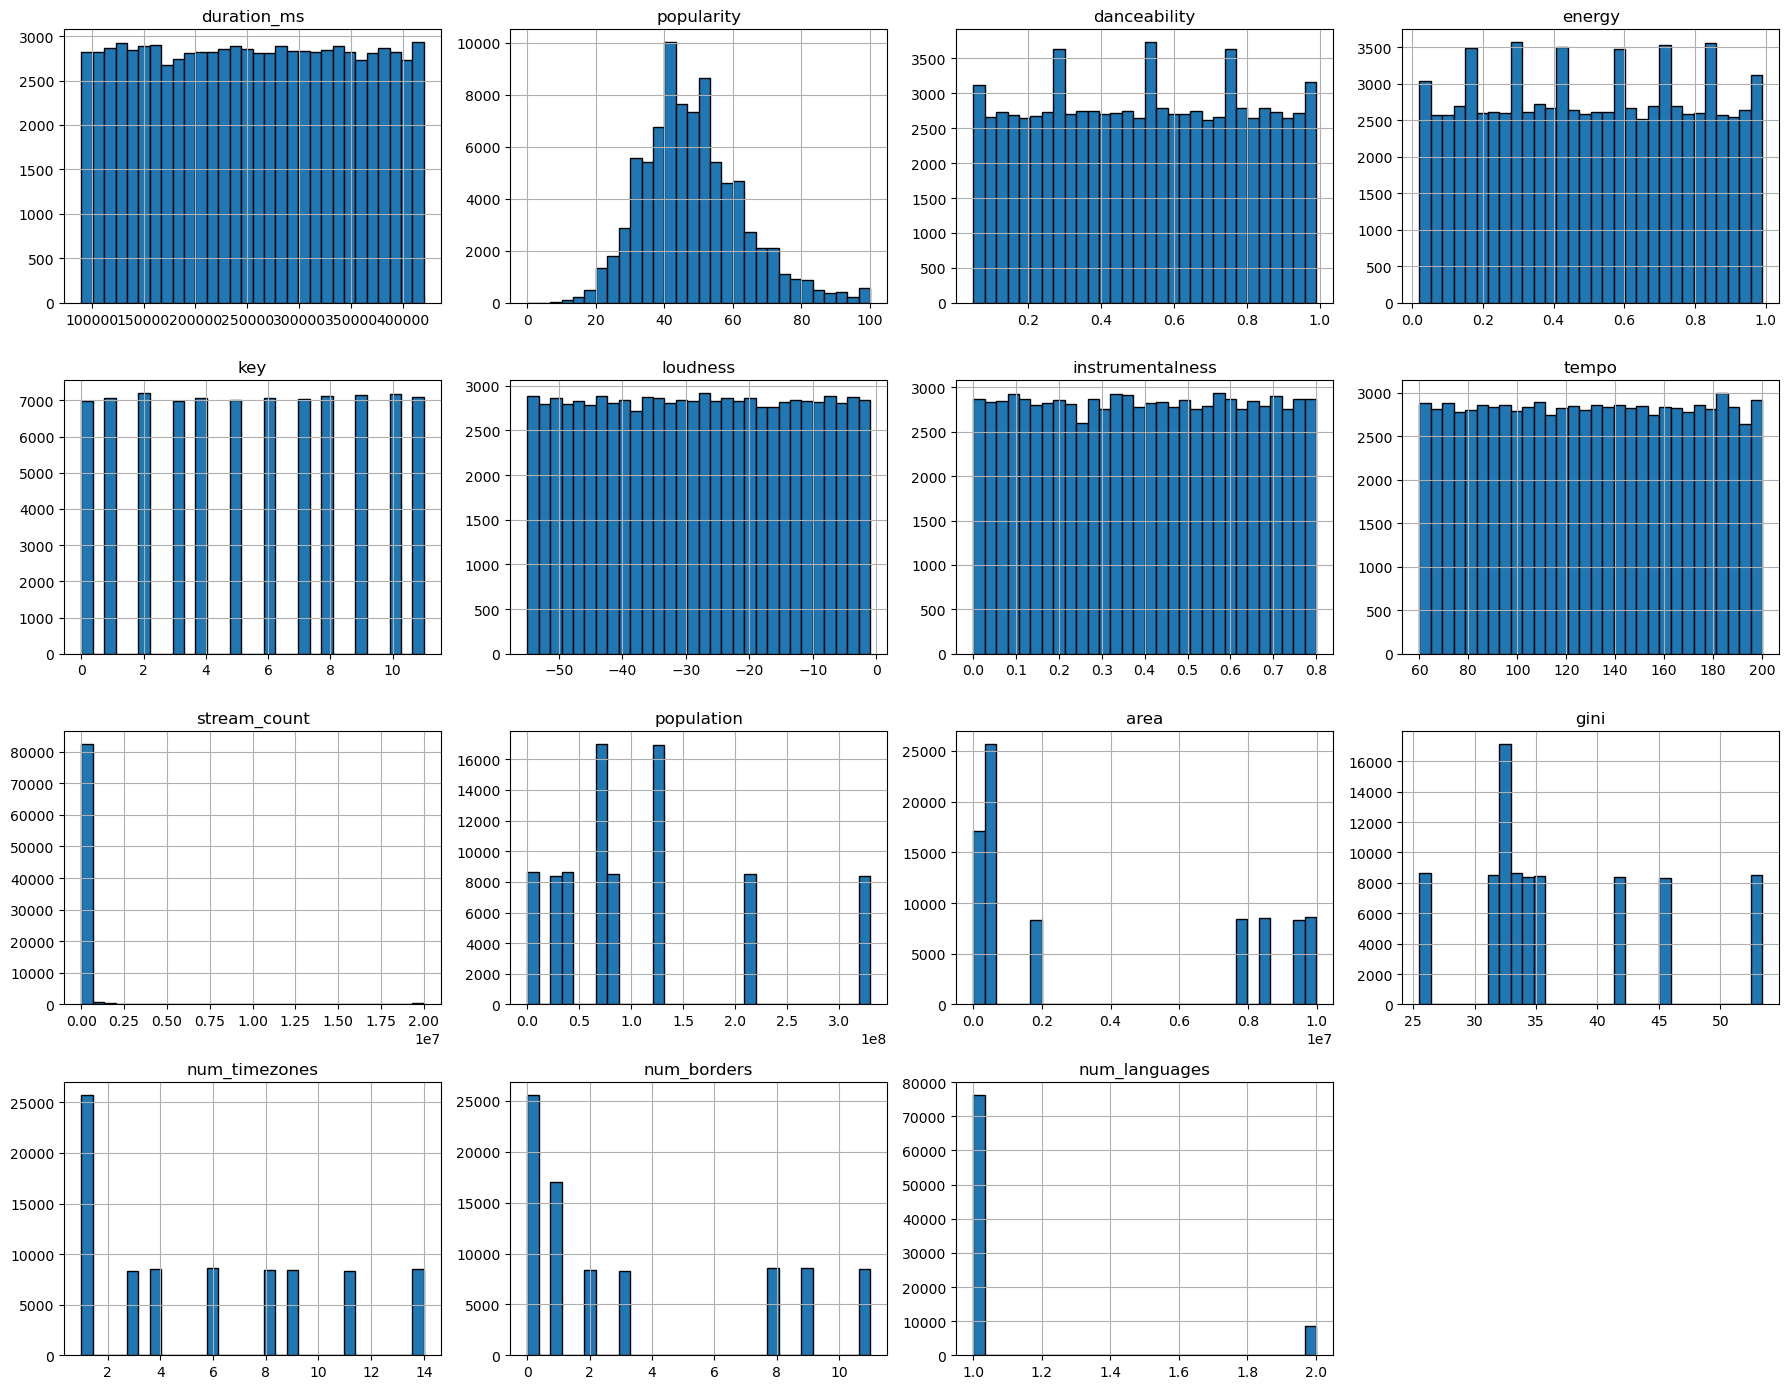

In [63]:
combined_df[num_cols].hist(
    bins=30,
    figsize=(18, 14),
    edgecolor="black"
)

plt.tight_layout()
plt.show()

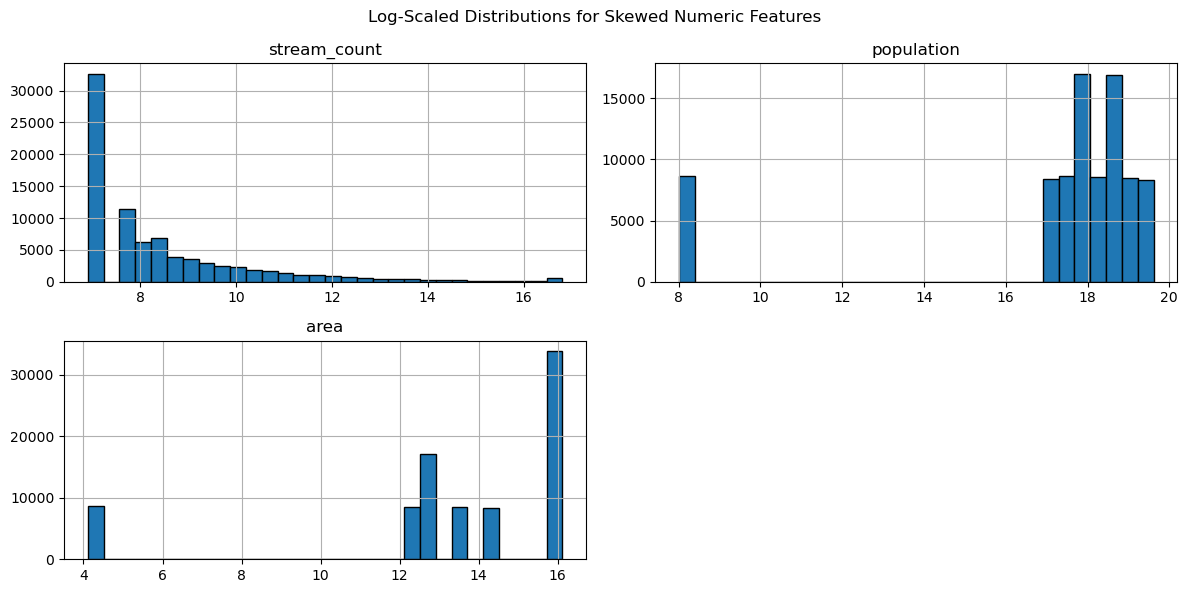

In [64]:
skewed_cols = ["stream_count", "population", "area"]

combined_df[skewed_cols].apply(lambda x: np.log1p(x)).hist(
    bins=30,
    figsize=(12, 6),
    edgecolor="black"
)

plt.suptitle("Log-Scaled Distributions for Skewed Numeric Features")
plt.tight_layout()
plt.show()

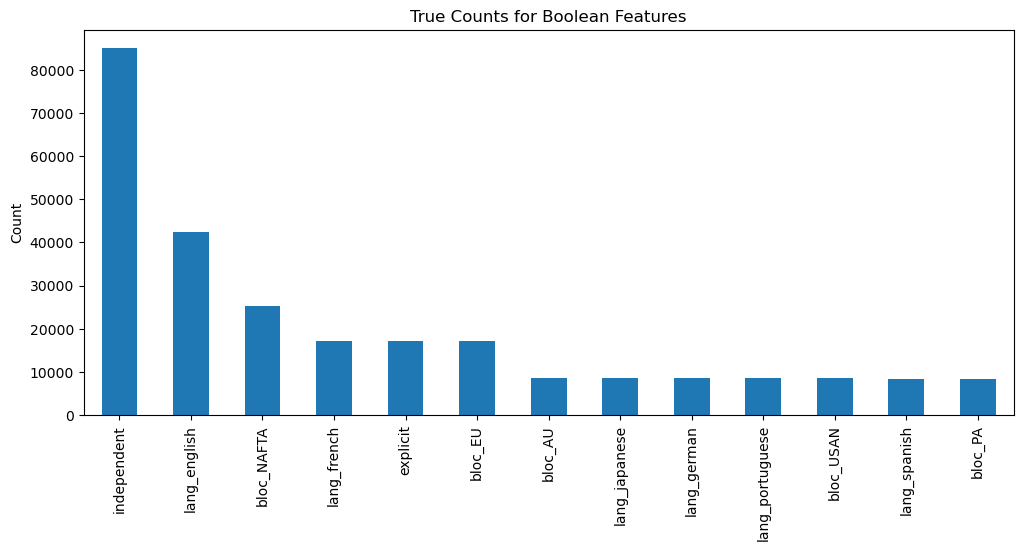

In [65]:
bool_cols = combined_df.select_dtypes(include="bool").columns

combined_df[bool_cols].sum().sort_values(ascending=False).plot(
    kind="bar",
    figsize=(12, 5)
)

plt.title("True Counts for Boolean Features")
plt.ylabel("Count")
plt.show()

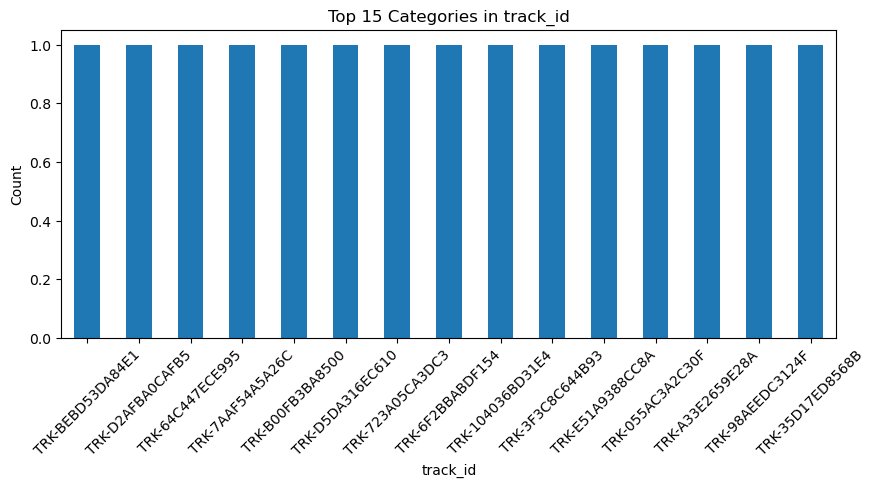

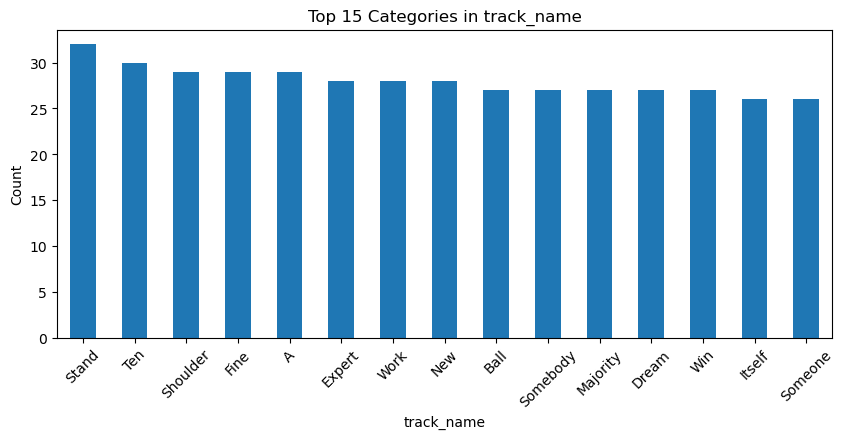

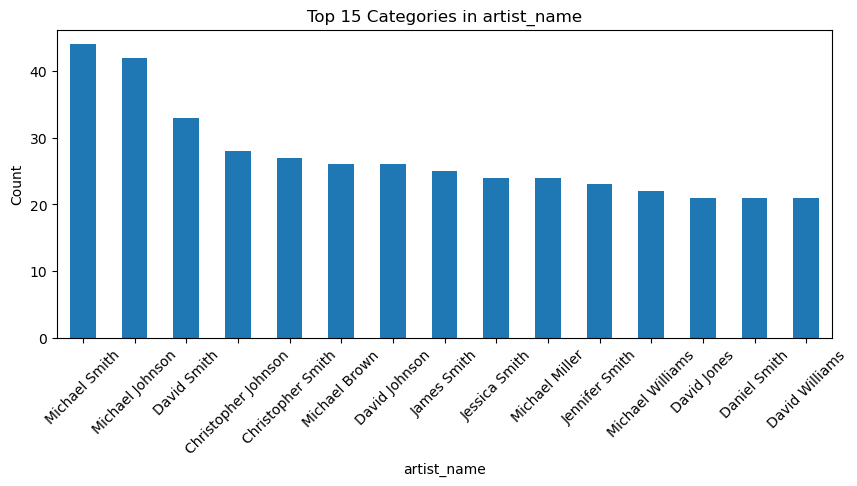

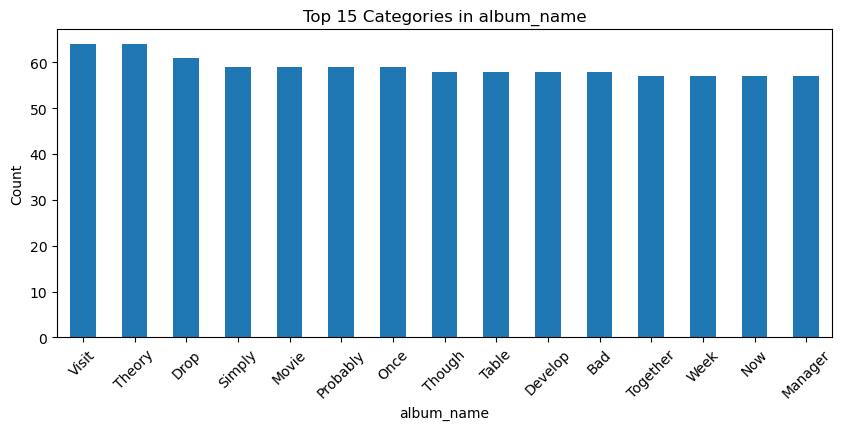

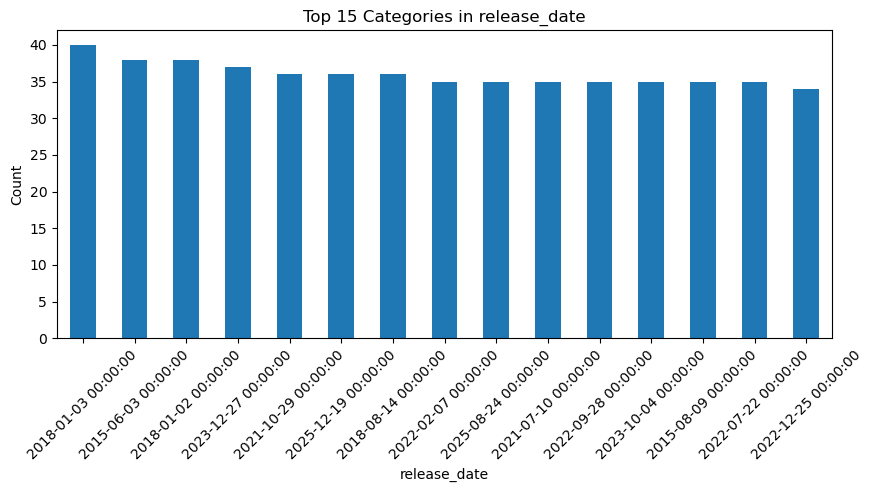

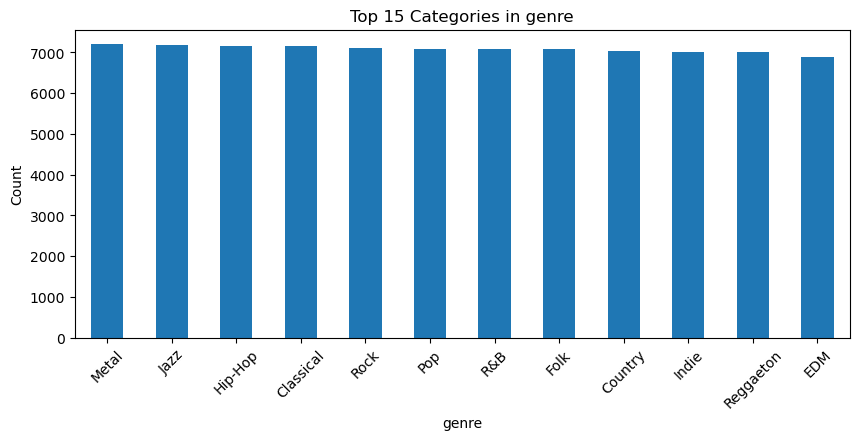

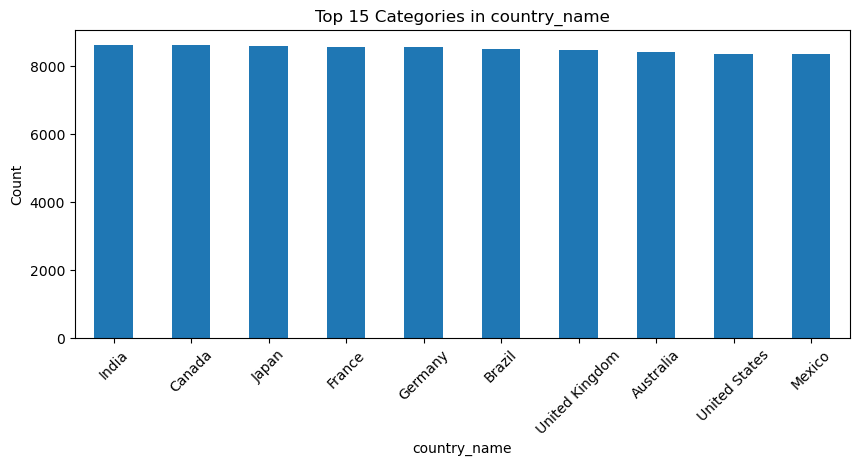

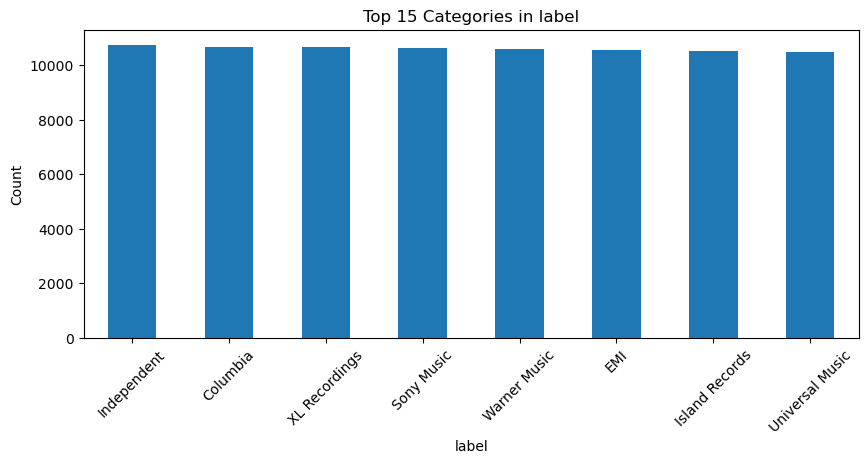

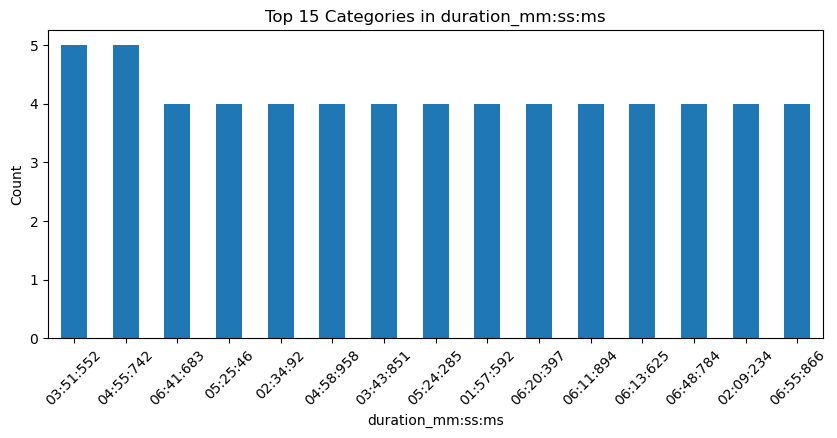

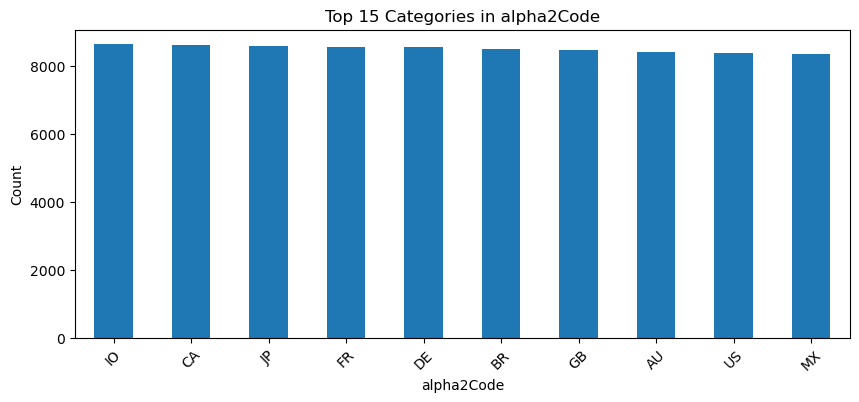

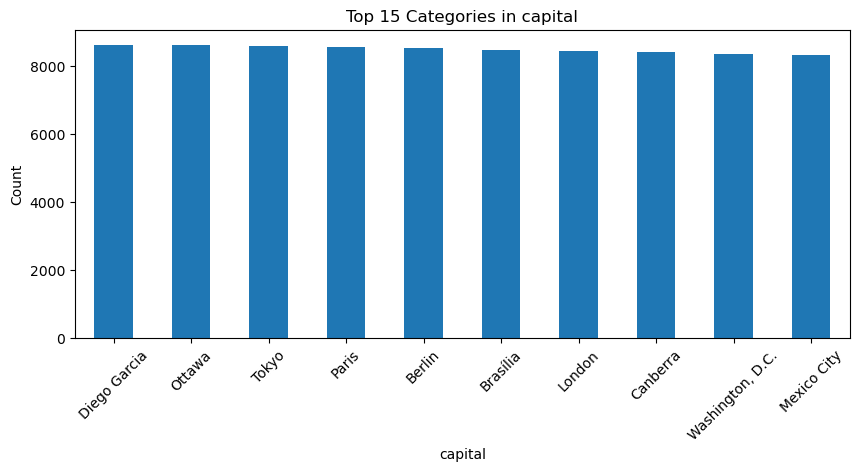

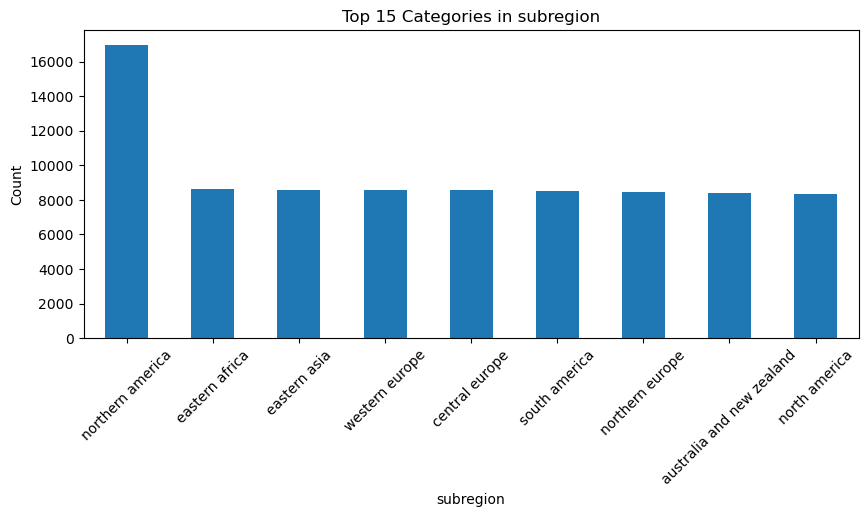

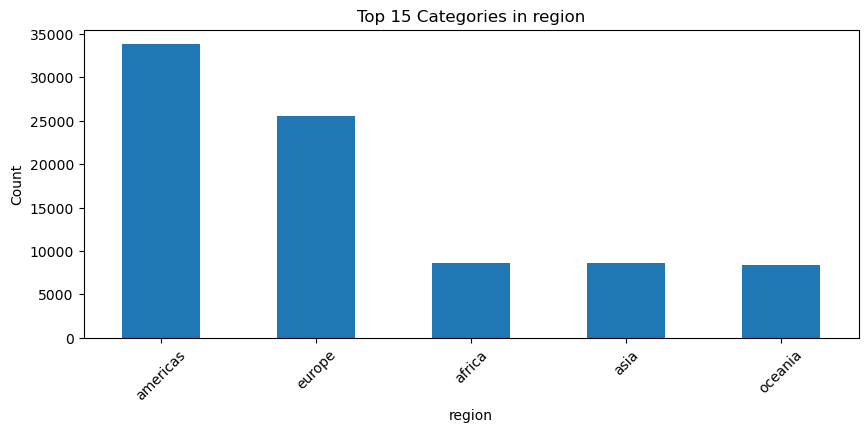

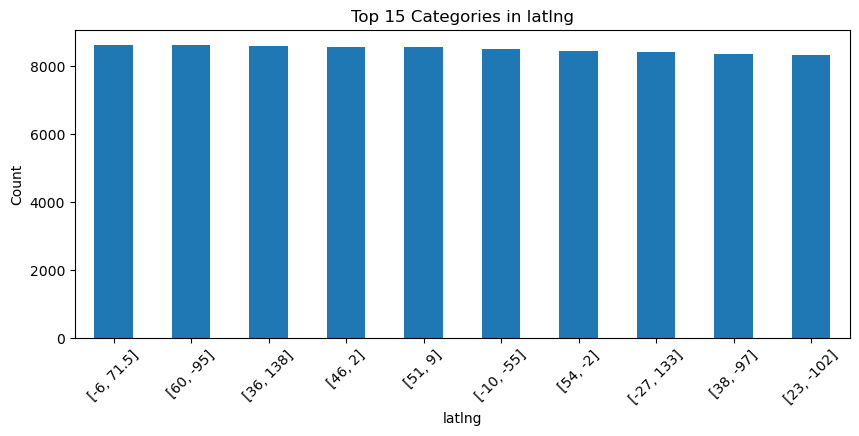

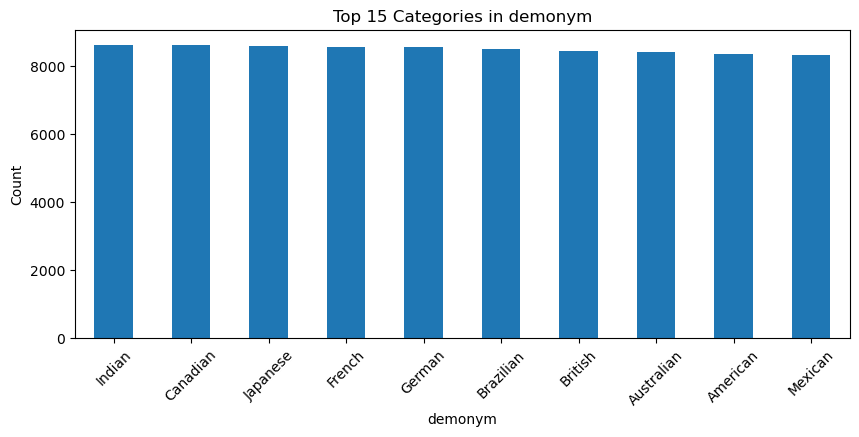

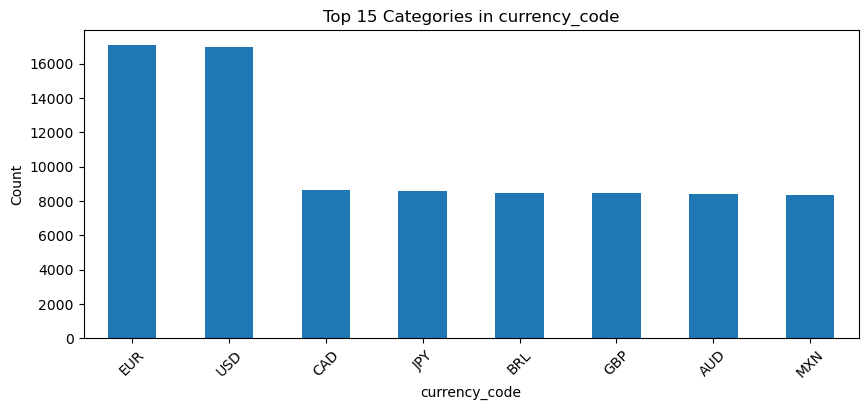

In [66]:
for col in cat_cols:
    if combined_df[col].nunique() > 2:
        combined_df[col].value_counts().head(15).plot(
            kind="bar",
            figsize=(10, 4)
        )
        plt.title(f"Top 15 Categories in {col}")
        plt.ylabel("Count")
        plt.xticks(rotation=45)
        plt.show()

### Artist Exploration

In [67]:
# Explore artists

artist_df = (
    combined_df
    .groupby('artist_name')
    .agg(
        num_songs=('track_id', 'count'),
        num_albums=('album_name', 'nunique'),
        mean_popularity=('popularity', 'mean'),
        median_popularity=('popularity', 'median'),
        total_streams=('stream_count', 'sum')
    )
    .reset_index()
)

In [68]:
artist_df.shape

(62364, 6)

In [69]:
artist_df.sort_values(by='num_songs', ascending=False).head(10)

,artist_name,num_songs,num_albums,mean_popularity,median_popularity,total_streams
42794,Michael Smith,44,44,50.704545,48.5,11585000
42517,Michael Johnson,42,41,49.214286,49.0,3577000
15690,David Smith,33,33,49.939394,50.0,961000
12082,Christopher Johnson,28,28,44.607143,40.5,515000
12302,Christopher Smith,27,27,50.407407,49.0,1598000
15469,David Johnson,26,26,47.000000,44.5,5058000
42256,Michael Brown,26,26,46.923077,46.5,280000
24699,James Smith,25,25,44.560000,41.0,389000
42624,Michael Miller,24,24,45.333333,47.0,689000
27989,Jessica Smith,24,24,46.833333,41.0,3381000


Text(0, 0.5, 'Artists')

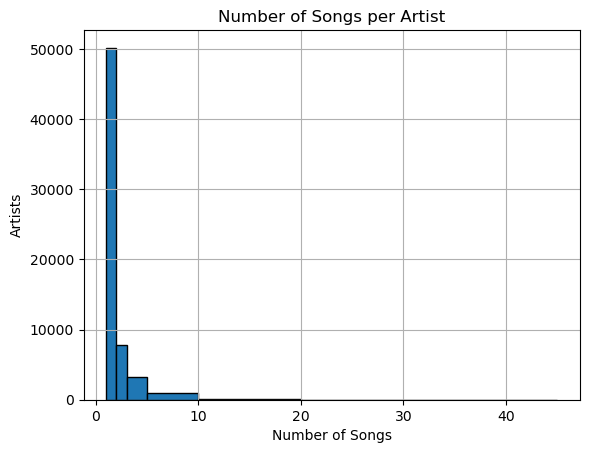

In [70]:
bins = [1, 2, 3, 5, 10, 20, 30, 40, 45]

artist_df["num_songs"].hist(bins=bins, edgecolor="black")
plt.title("Number of Songs per Artist")
plt.xlabel("Number of Songs")
plt.ylabel("Artists")

Text(0, 0.5, 'Artists')

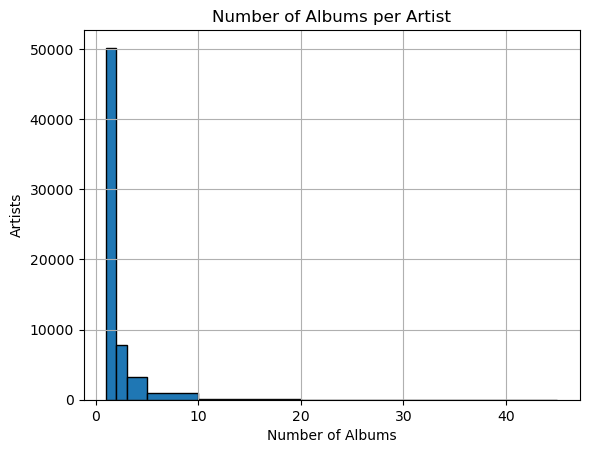

In [71]:
bins = [1, 2, 3, 5, 10, 20, 30, 40, 45]

artist_df["num_albums"].hist(bins=bins, edgecolor="black")
plt.title("Number of Albums per Artist")
plt.xlabel("Number of Albums")
plt.ylabel("Artists")

Interesting insight - The number of albums per artist looks identical to the number of songs per artist, indicating that the majority of songs are relased individually.

In [72]:
artist_df.sort_values(by='mean_popularity', ascending=False).head(30)

,artist_name,num_songs,num_albums,mean_popularity,median_popularity,total_streams
46066,Nicholas Graham,1,1,100.0,100.0,14458000
58190,Thomas Park,1,1,100.0,100.0,20000000
22635,Harold Price,1,1,100.0,100.0,20000000
38645,Luis Waters,1,1,100.0,100.0,1708000
28522,Jodi Bishop,1,1,100.0,100.0,20000000
19472,Elizabeth Stanley,1,1,100.0,100.0,8383000
25095,Janet Ross,1,1,100.0,100.0,4952000
6646,Bobby Gomez,1,1,100.0,100.0,20000000
21985,Glenn Murphy,1,1,100.0,100.0,20000000
55217,Stanley Baldwin,1,1,100.0,100.0,20000000


In [73]:
artist_df.sort_values(by='total_streams', ascending=False).head(30)

,artist_name,num_songs,num_albums,mean_popularity,median_popularity,total_streams
4792,Anthony Walker,5,5,62.400000,46.0,40008000
48078,Peter Hall,3,3,71.666667,90.0,34132000
49081,Rebecca Brown,9,9,60.333333,50.0,27892000
35203,Kimberly Smith,12,12,59.750000,57.0,26801000
25664,Jason Owens,4,4,61.250000,60.5,25351000
52075,Samantha Johnson,6,6,58.500000,48.5,24405000
9004,Caitlin Smith,2,2,89.000000,89.0,24327000
55447,Stephanie Lee,6,6,70.666667,73.5,24221000
2086,Amanda Henry,6,6,65.666667,57.0,21858000
59146,Todd Rodriguez,2,2,86.500000,86.5,21802000


An interesting insight came from exploring the Artist Data Frame. This data has a columns showing the mean and median popularity for each artist - surprisingly there are more than 30 artists with a perfect 100 popularity score for both mean and median, which also may be due to many artists having only 1 song. However, when inspecting the top 30 total streamed, none of the artists have a mean or median popularity score of 100. We need to inspect further to determine if popularity is acutually the best column to use as our target data. Stream Count could be a better primary target feature to focus on for musicians and labels.

Let's inspect this information in the combined dataframe.

In [74]:
combined_df[['track_name', 'artist_name', 'album_name', 'popularity', 'stream_count']].sort_values(by='popularity', ascending=False).head(20)

,track_name,artist_name,album_name,popularity,stream_count
83048,Professor free,Kathy Mcconnell,My answer,100,9150000
2748,Front sure capital how,Marissa Green,Yeah,100,20000000
29249,President production both,Justin Sanders,Hand huge,100,8524000
73145,This coach,Jason Ewing,Picture them,100,4528000
38411,Day cut maintain second,John Hughes,Example,100,20000000
64723,Place resource gas camera,Pamela Graham,For military,100,20000000
71742,Collection,Alicia Arnold,Think,100,7249000
76999,Me thank,Jacob Townsend,Early mean,100,20000000
47497,Relationship,Nichole Lawson,Capital,100,20000000
78057,Represent public,Christopher Jones,West,100,7368000


In [75]:
combined_df[['track_name', 'artist_name', 'album_name', 'popularity', 'stream_count']].sort_values(by='stream_count', ascending=False).head(20)

,track_name,artist_name,album_name,popularity,stream_count
40577,Conference read you experience,Amy Shepherd,Young rule,100,20000000
60390,Million side,Nicholas Fowler,Second,99,20000000
84283,Recognize fly,Allison Hale,Get meeting,96,20000000
29859,It gas,Daniel Lewis,Order,97,20000000
48812,Camera,Stephanie Roach,Drop,93,20000000
60004,List,Caitlin Smith,Listen,100,20000000
29697,Only address,Manuel Yang,Hope current,97,20000000
74897,Tend scientist,Lauren Roberts,Teacher these,89,20000000
74829,Place piece,Tracy Pope,Yard,87,20000000
74801,Parent of teach,Cindy Figueroa,Religious spring,85,20000000


Exploring the main data set, we can see that the stream count clearly has a miximum of 20 million streams. There are more than 30 records with 20 mil streams listed, and several have a popularity score of 100, but there are also many with a maxed out stream count that do not have a perfect 100 popularity score. This tells us that number of stream counts is not the only factor taken into account to determine the popularity score, so it is still the best for our primary target feature. However stream count can still be very useful marketing and budget information for artists and labels, so it will be a strong secondary target feature.

### Label Exploration

In [76]:
label_df = (
    combined_df
    .groupby('label')
    .agg(
        num_artists=('artist_name', 'count'),
        num_songs=('track_id', 'count'),
        num_albums=('album_name', 'nunique'),
        mean_popularity=('popularity', 'mean'),
        median_popularity=('popularity', 'median'),
        total_streams=('stream_count', 'sum')
    )
    .reset_index()
)

In [77]:
label_df['stream_count_rank'] = label_df['total_streams'].rank(method='min', ascending=False).astype(int)
label_df['num_artist_Rank'] = label_df['num_artists'].rank(method='min', ascending=False).astype(int)
label_df['num_songs_rank'] = label_df['num_albums'].rank(method='min', ascending=False).astype(int)
label_df['mean_pop_rank'] = label_df['mean_popularity'].rank(method='min', ascending=False).astype(int)

In [78]:
label_df.sort_values(by='mean_popularity', ascending=False)

,label,num_artists,num_songs,num_albums,mean_popularity,median_popularity,total_streams,stream_count_rank,num_artist_Rank,num_songs_rank,mean_pop_rank
4,Sony Music,10620,10620,6324,48.322693,47.0,2419227000,2,4,5,1
1,EMI,10572,10572,6376,48.307037,47.0,2451406000,1,6,3,2
2,Independent,10763,10763,6388,48.260894,47.0,2383638000,3,1,2,3
7,XL Recordings,10684,10684,6481,48.210876,47.0,2103647000,8,3,1,4
5,Universal Music,10496,10496,6260,48.207508,47.0,2276440000,4,8,7,5
0,Columbia,10685,10685,6371,48.090220,46.0,2162393000,7,2,4,6
3,Island Records,10519,10519,6299,48.005609,46.0,2179477000,6,7,6,7
6,Warner Music,10615,10615,6238,47.901083,46.0,2242179000,5,5,8,8


There are 8 total labels that represent all of the artists and songs in the data set. When ranking the lables on the most stream count, number of artists they represent, and number of songs, we see that there is not one label that ranks highest on all three. This indicates that there is not a dominant label that produces the most popular songs all of the time.

### Song Exploration

In [88]:
# What are the top songs with a perfect 100 popularity score and 2 Mil Streams?

condition1 = combined_df['popularity'] == 100
condition2 = combined_df['stream_count'] == 20000000
combined_conditions = condition1 & condition2

Top_Songs = combined_df[combined_conditions]
print(f"There are {len(Top_Songs)} songs with a popularity score of 100 and 20,000,000 streams")
print(f"There are {Top_Songs['artist_name'].nunique()} artists who have at least one song with a popularity score of 100 and 20,000,000 streams")

There are 201 songs with a popularity score of 100 and 20,000,000 streams
There are 201 artists who have at least one song with a popularity score of 100 and 20,000,000 streams


Another interesting insight from exploring the top songs - there are no artists that have more than 1 song that is the top in both popularity and stream_count. How does this compare to our full dataset?

In [89]:
max_stream_count = combined_df[combined_df['stream_count'] == 20000000]
print(f"There are {len(max_stream_count)} songs with 20,000,000 streams")

There are 458 songs with 20,000,000 streams


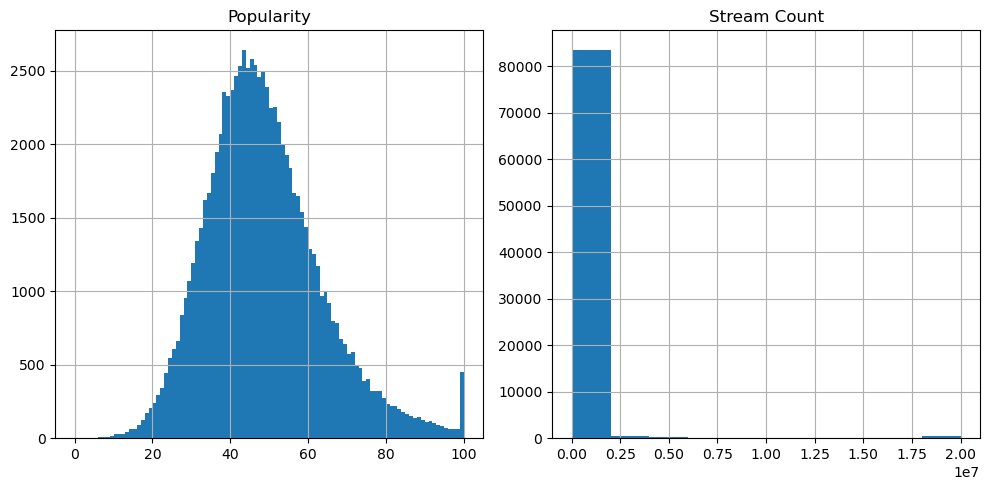

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

combined_df.hist('popularity', bins=100, ax=axes[0])
combined_df.hist('stream_count', bins=10, ax=axes[1])

axes[0].set_title("Popularity")
axes[1].set_title("Stream Count")

plt.tight_layout()
plt.show()

When visualizing the distributions of <strong>Popularity</strong> and <strong>Stream Count</strong>, we see that Popularity is normally distributed with an additional spike at 100, whereas Stream Count is heavily right skewed indicating that the vast majority of songs have a stream count of less than 2.5 Million. We know the maxmimum stream count is 20 Million, so to more accurately compare the relationship between these two we need to use a logrithmic scale for stream count.

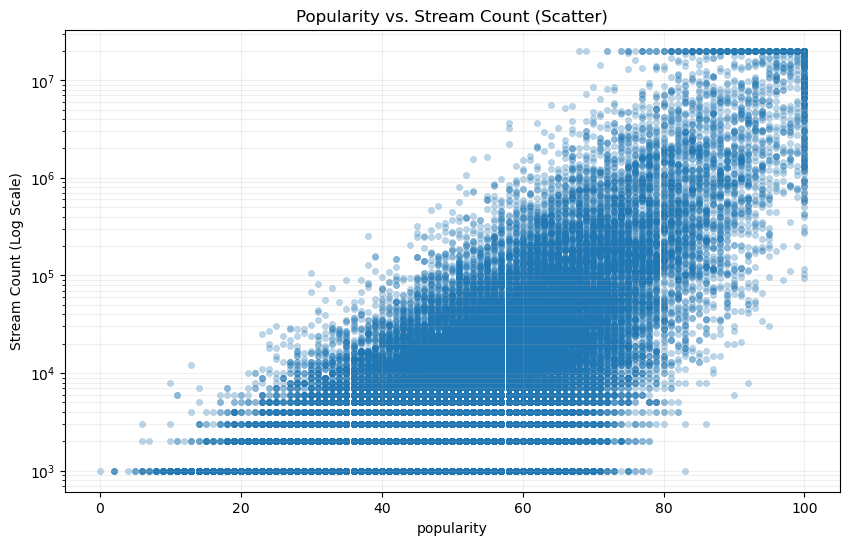

In [24]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=combined_df, 
    x='popularity', 
    y='stream_count', 
    alpha=0.3,
    edgecolor=None,
    s=20
)

plt.yscale('log')
plt.title('Popularity vs. Stream Count (Scatter)')
plt.ylabel('Stream Count (Log Scale)')
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

In this scatter plot we can see the relationship between popularity and stream count shows a positive correlation as expected. We can also see some unexpected groupings showing that popularity scores of 100 have a wide range of stream counts, but do not drop below 100,000, and stream counts maxed at 20 million do not drop below popularity scores of approximately 65.

In [28]:
analysis_date = combined_df["release_date"].max()

combined_df["days_since_release"] = (
    analysis_date - combined_df["release_date"]
).dt.days

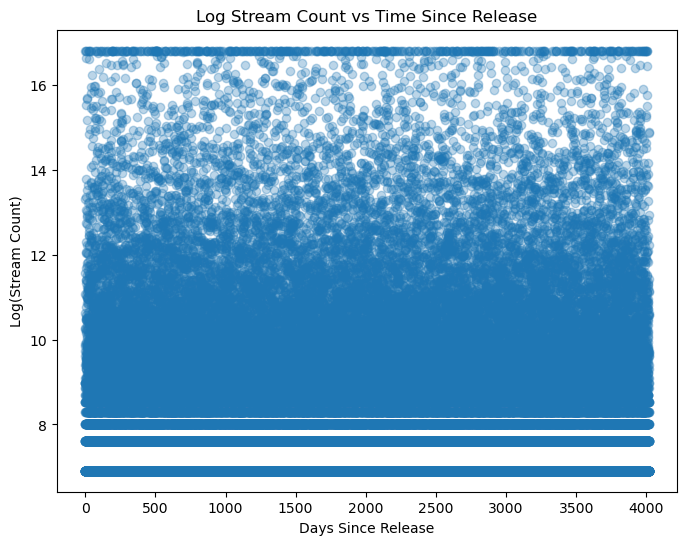

In [29]:
plt.figure(figsize=(8, 6))
plt.scatter(
    combined_df["days_since_release"],
    np.log1p(combined_df["stream_count"]),
    alpha=0.3
)
plt.xlabel("Days Since Release")
plt.ylabel("Log(Stream Count)")
plt.title("Log Stream Count vs Time Since Release")
plt.show()


In [30]:
combined_df["streams_per_day"] = (
    combined_df["stream_count"] / combined_df["days_since_release"].clip(lower=1)
)

In [31]:
combined_df[['track_name','artist_name','streams_per_day','release_date','stream_count','popularity']].sort_values(by='streams_per_day', ascending=False).head(10)

,track_name,artist_name,streams_per_day,release_date,stream_count,popularity
79818,Light would,Glenn Murphy,1.000000e+07,2025-12-29,20000000,100
61906,Federal floor,Melissa Hansen,5.673667e+06,2025-12-28,17021000,87
34631,Base,Anthony Walker,5.000000e+06,2025-12-27,20000000,92
6465,Would exactly between mind,Anita Torres,4.000000e+06,2025-12-26,20000000,91
63960,Special,Kimberly James,1.112600e+06,2025-12-26,5563000,100
14195,Who treat technology around response,Johnny Steele,1.000000e+06,2025-12-11,20000000,100
79908,Those know star,Ruben Williamson,8.000000e+05,2025-12-06,20000000,88
76485,Yourself act,Mr. Walter Sullivan MD,7.142857e+05,2025-12-03,20000000,100
47532,Tell rest avoid probably,Kimberly Bowman,6.802500e+05,2025-12-07,16326000,96
75220,Spring support over,William Anderson,6.250000e+05,2025-11-29,20000000,98


### Genre Exploration

In [32]:
combined_df['genre'].nunique()

12

In [33]:
genre_df = (
    combined_df
    .groupby('genre')
    .agg(
        num_songs=('track_id', 'count'),
        num_artists=('artist_name', 'count'),
        num_albums=('album_name', 'nunique'),
        mean_popularity=('popularity', 'mean'),
        median_popularity=('popularity', 'median'),
        total_streams=('stream_count', 'sum')
    )
    .reset_index()
)

In [34]:
genre_df['num_songs_rank'] = genre_df['num_songs'].rank(method='min', ascending=False).astype(int)
genre_df['num_artists_rank'] = genre_df['num_artists'].rank(method='min', ascending=False).astype(int)
genre_df['mean_pop_rank'] = genre_df['mean_popularity'].rank(method='min', ascending=False).astype(int)
genre_df['median_pop_rank'] = genre_df['median_popularity'].rank(method='min', ascending=False).astype(int)
genre_df['total_stream_rank'] = genre_df['total_streams'].rank(method='min', ascending=False).astype(int)

In [35]:
genre_df.sort_values(by='mean_pop_rank', ascending=True)

,genre,num_songs,num_artists,num_albums,mean_popularity,median_popularity,total_streams,num_songs_rank,num_artists_rank,mean_pop_rank,median_pop_rank,total_stream_rank
8,Pop,7088,7088,4498,48.375564,47.0,1538132000,6,6,1,1,6
9,R&B,7080,7080,4550,48.364972,47.0,1624312000,7,7,2,1,2
0,Classical,7154,7154,4641,48.364971,47.0,1558455000,4,4,3,1,4
4,Hip-Hop,7156,7156,4557,48.360257,47.0,1906753000,3,3,4,1,1
2,EDM,6885,6885,4433,48.208424,47.0,1532953000,12,12,5,1,7
7,Metal,7198,7198,4565,48.192276,47.0,1604970000,1,1,6,1,3
1,Country,7027,7027,4462,48.170912,46.0,1440463000,9,9,7,9,10
5,Indie,7001,7001,4475,48.125982,47.0,1257966000,10,10,8,1,12
3,Folk,7078,7078,4493,48.096779,47.0,1538901000,8,8,9,1,5
11,Rock,7110,7110,4553,47.968354,46.0,1452050000,5,5,10,9,8


Once again we find that the popularity score and total number of streams do not align. In the Genre Data Frame we can see that the pop genre is the most popular but is the 6th most streamed whereas the hip hop genre is the most streamed but is the 4th highest popular. While this may seem at first glance as misleading, it actually indicates that there are other features that contribute to the ultimate popularity and success of a song. When we show the data on a scatter plot (below) with the hue set to genres we can easily see that there is no visable pattern or clusters for genre, and each genre has a wide distribution of popularity and stream count.

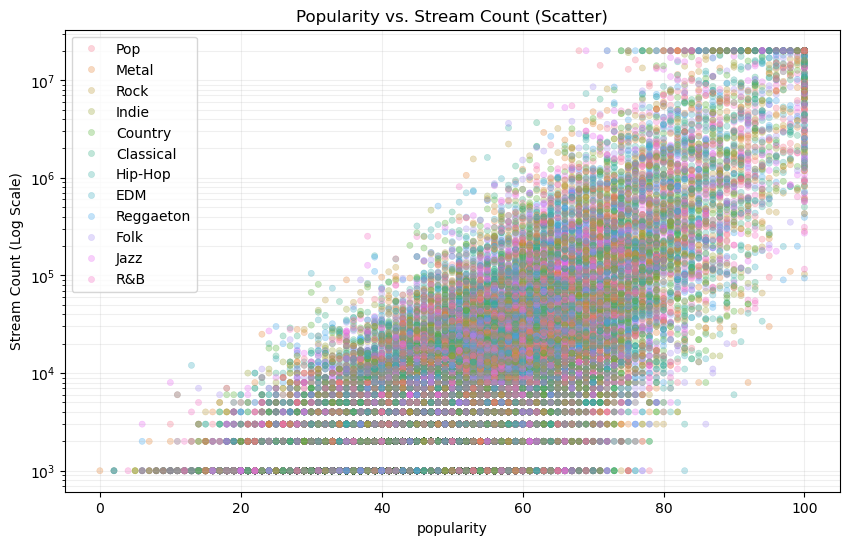

In [36]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=combined_df, 
    x='popularity', 
    y='stream_count',
    hue='genre',
    alpha=0.3,
    edgecolor=None,
    s=20
)

plt.yscale('log')
plt.title('Popularity vs. Stream Count (Scatter)')
plt.ylabel('Stream Count (Log Scale)')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

### Region/Country

In [37]:
combined_df.groupby("region")["popularity"].mean().sort_values(ascending=False)

region
asia        48.349959
europe      48.276260
americas    48.098849
oceania     48.048287
africa      48.008929
Name: popularity, dtype: float64

In [38]:
combined_df.groupby("region")["stream_count"].mean().sort_values(ascending=False)

region
asia        234572.427456
europe      221648.559800
americas    211246.885081
africa      208339.285714
oceania     191179.590866
Name: stream_count, dtype: float64

In [39]:
combined_df.groupby("country_name")["popularity"].mean().sort_values(ascending=False)

country_name
United Kingdom    48.409419
Japan             48.349959
France            48.341478
Brazil            48.316993
Germany           48.079326
Canada            48.061753
United States     48.059133
Australia         48.048287
India             48.008929
Mexico            47.954884
Name: popularity, dtype: float64

In [40]:
combined_df.groupby("country_name")["stream_count"].mean().sort_values(ascending=False)

country_name
Japan             234572.427456
France            230154.430676
Mexico            227574.154068
United Kingdom    221204.709502
Canada            217715.264074
Germany           213574.587575
India             208339.285714
Brazil            206760.900306
United States     192845.104142
Australia         191179.590866
Name: stream_count, dtype: float64

<Axes: title={'center': 'popularity'}, xlabel='country_name'>

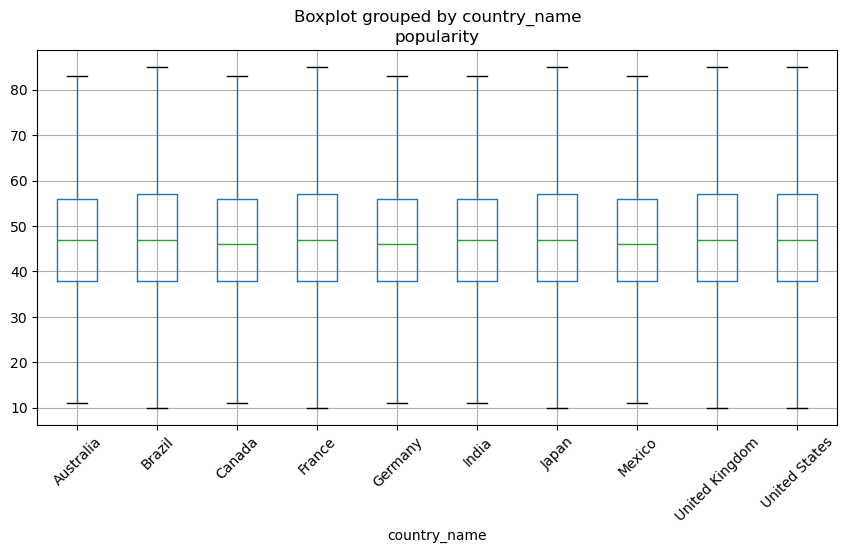

In [41]:
combined_df.boxplot(
    column="popularity",
    by="country_name",
    showfliers=False,
    rot=45,
    figsize=(10, 5)
)


## Correlation Analysis

In [42]:
num_cols

Index(['duration_ms', 'popularity', 'danceability', 'energy', 'key',
       'loudness', 'instrumentalness', 'tempo', 'stream_count', 'population',
       'area', 'gini', 'num_timezones', 'num_borders', 'num_languages'],
      dtype='object')

In [43]:
cat_cols

Index(['track_id', 'track_name', 'artist_name', 'album_name', 'release_date',
       'genre', 'mode', 'country_name', 'explicit', 'label',
       'duration_mm:ss:ms', 'alpha2Code', 'capital', 'subregion', 'region',
       'latlng', 'demonym', 'independent', 'currency_code', 'lang_english',
       'lang_french', 'lang_german', 'lang_japanese', 'lang_portuguese',
       'lang_spanish', 'bloc_AU', 'bloc_EU', 'bloc_NAFTA', 'bloc_PA',
       'bloc_USAN'],
      dtype='object')

### Numerical Feature Correlation

In [44]:
num_cols = combined_df.select_dtypes(include=np.number).columns

In [45]:
num_cols

Index(['duration_ms', 'popularity', 'danceability', 'energy', 'key',
       'loudness', 'instrumentalness', 'tempo', 'stream_count', 'population',
       'area', 'gini', 'num_timezones', 'num_borders', 'num_languages',
       'days_since_release', 'streams_per_day'],
      dtype='object')

In [46]:
corr_matrix = combined_df[num_cols].corr()
corr_matrix['popularity'].sort_values(ascending=False)

popularity            1.000000
stream_count          0.357563
streams_per_day       0.040876
loudness              0.003242
danceability          0.003227
num_timezones         0.003093
num_borders           0.002845
instrumentalness      0.002093
gini                  0.001062
population            0.000777
energy               -0.000318
duration_ms          -0.000506
num_languages        -0.002303
tempo                -0.002734
area                 -0.002872
key                  -0.003242
days_since_release   -0.004373
Name: popularity, dtype: float64

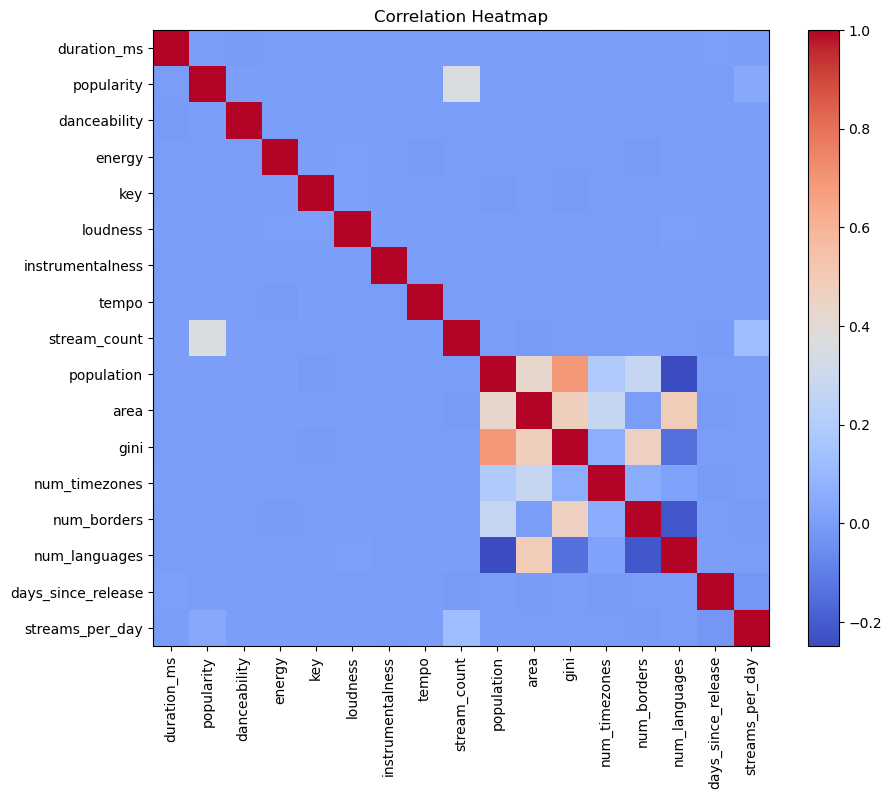

In [47]:
plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, cmap="coolwarm")
plt.colorbar()
plt.xticks(range(len(num_cols)), num_cols, rotation=90)
plt.yticks(range(len(num_cols)), num_cols)
plt.title("Correlation Heatmap")
plt.show()

The Pearson corrleation analysis of numeric features shows that no single numeric feature has a strong linear relationship with track popularity, with the exception of stream count which is our other target feature. This suggests that the track popularity is not driven by simple linear effects, and is more likely influenced by non-linear interactions, aggregation-level effects, and/or possibly categorical features.

### Categorical Feature Correlation

In [48]:
for col in cat_cols:
    if combined_df[col].apply(lambda x: isinstance(x, list)).any():
        combined_df[col] = combined_df[col].apply(tuple)

In [49]:
binary_cat_cols = [
    col for col in cat_cols
    if combined_df[col].nunique() == 2
]

multi_cat_cols = [
    col for col in cat_cols
    if combined_df[col].nunique() > 2
]

In [50]:
for col in binary_cat_cols:
    print(f"\n{col.upper()}")
    display(
        combined_df.groupby(col)["popularity"]
        .agg(["mean", "median", "count"])
        .sort_values("mean", ascending=False)
    )



MODE


,mean,median,count
mode,,,
minor,48.186124,47.0,42461
major,48.140776,46.0,42493



EXPLICIT


,mean,median,count
explicit,,,
False,48.169973,47.0,67852
True,48.137528,47.0,17102



LANG_ENGLISH


...

,mean,median,count
bloc_NAFTA,,,
False,48.221874,47.0,59651
True,48.025689,46.0,25303



BLOC_PA


,mean,median,count
bloc_PA,,,
False,48.186126,47.0,76620
True,47.954884,46.0,8334



BLOC_USAN


,mean,median,count
bloc_USAN,,,
True,48.316993,47.0,8486
False,48.146401,47.0,76468


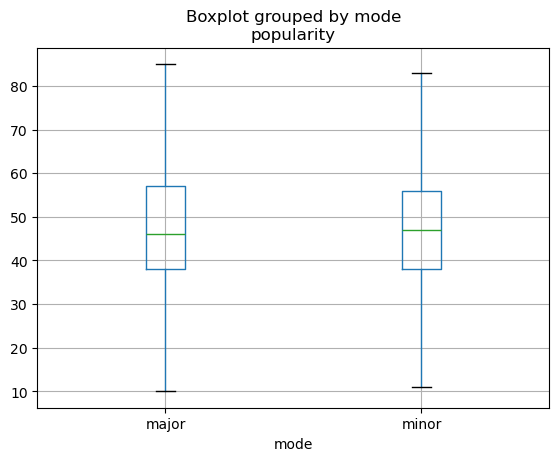

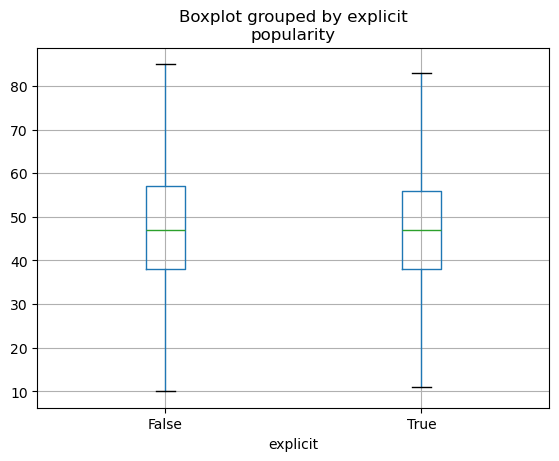

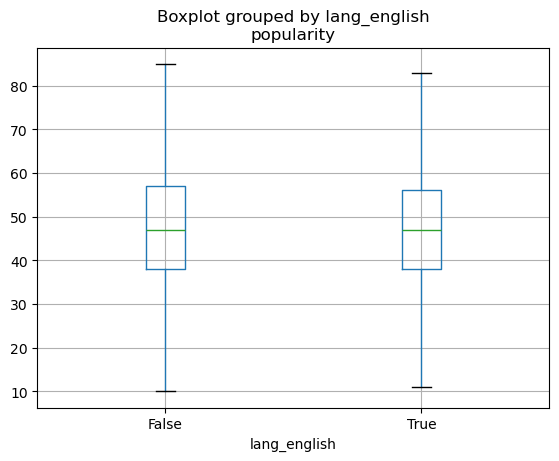

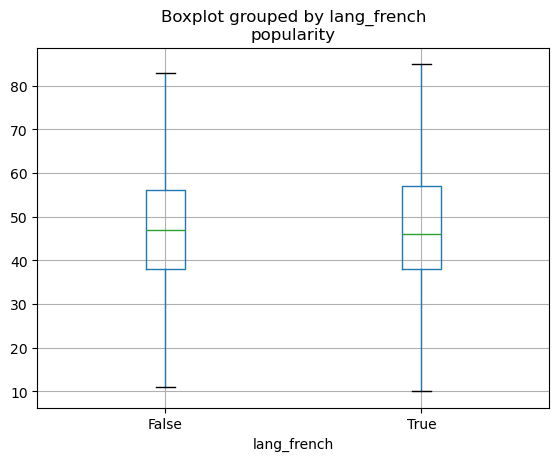

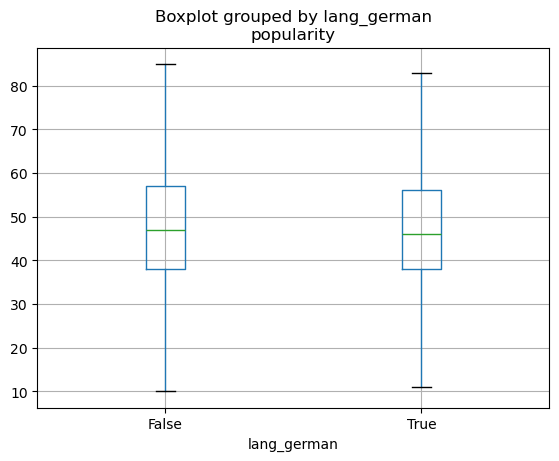

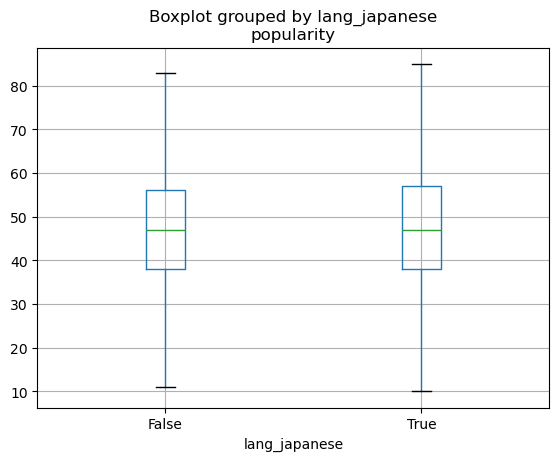

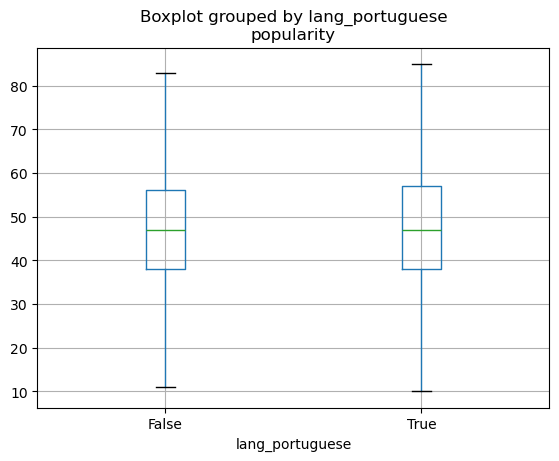

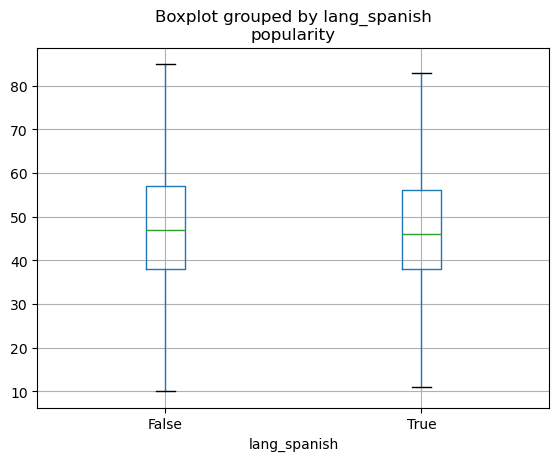

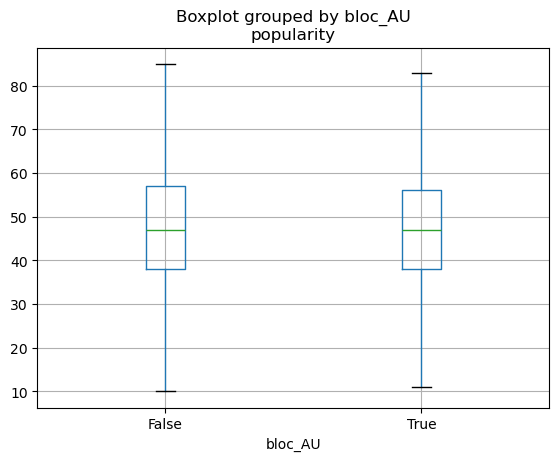

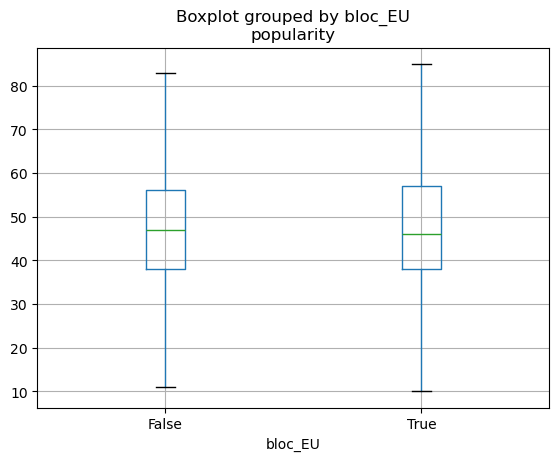

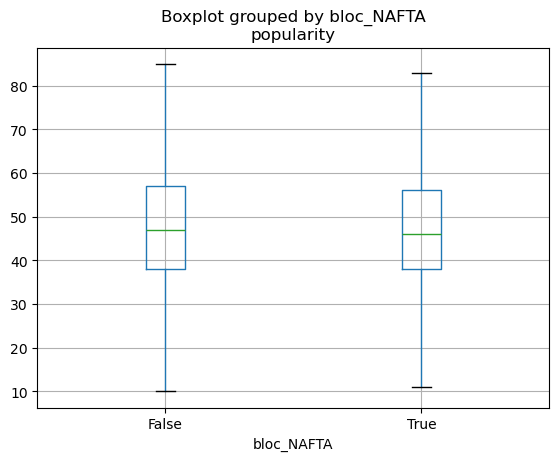

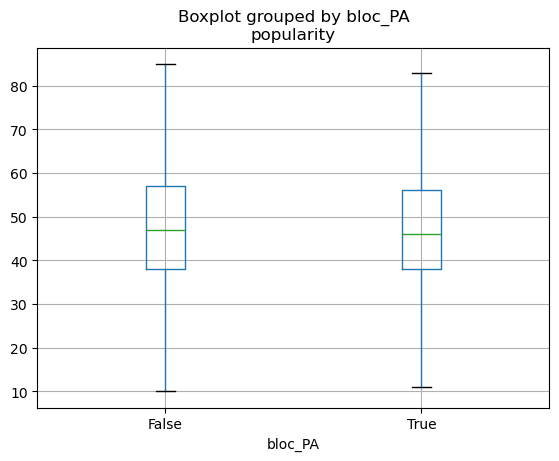

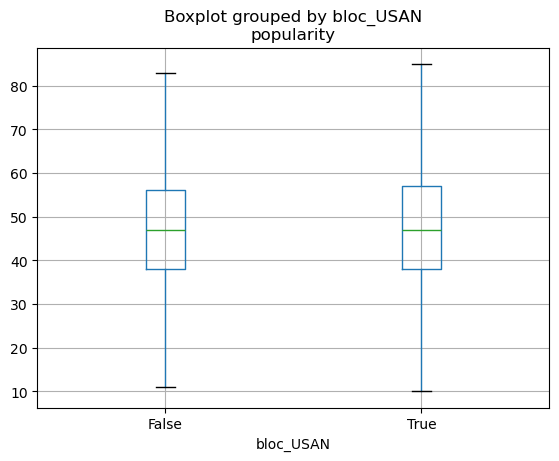

In [52]:
for col in binary_cat_cols:
    combined_df.boxplot(column="popularity", showfliers=False, by=col)



Analyzing: track_id


,mean,median,count
track_id,,,
TRK-BEBD53DA84E1,55.0,55.0,1
TRK-7AAF54A5A26C,50.0,50.0,1
TRK-B00FB3BA8500,44.0,44.0,1
TRK-104036BD31E4,42.0,42.0,1
TRK-3F3C8C644B93,41.0,41.0,1
TRK-64C447ECE995,39.0,39.0,1
TRK-D2AFBA0CAFB5,38.0,38.0,1
TRK-D5DA316EC610,37.0,37.0,1
TRK-723A05CA3DC3,34.0,34.0,1



Analyzing: track_name


,mean,median,count
track_name,,,
Stand,53.312500,51.5,32
Ten,52.400000,47.0,30
Work,51.357143,49.5,28
New,49.464286,45.5,28
Shoulder,48.551724,47.0,29
Fine,48.103448,49.0,29
Expert,46.607143,45.0,28
Somebody,46.592593,46.0,27
A,45.000000,41.0,29



Analyzing: artist_name


...

,mean,median,count
latlng,,,
"[54, -2]",48.409419,47.0,8451
"[36, 138]",48.349959,47.0,8581
"[46, 2]",48.341478,47.0,8554
"[-10, -55]",48.316993,47.0,8486
"[51, 9]",48.079326,46.0,8547
"[60, -95]",48.061753,46.0,8615
"[38, -97]",48.059133,47.0,8354
"[-27, 133]",48.048287,47.0,8408
"[-6, 71.5]",48.008929,47.0,8624



Analyzing: demonym


,mean,median,count
demonym,,,
British,48.409419,47.0,8451
Japanese,48.349959,47.0,8581
French,48.341478,47.0,8554
Brazilian,48.316993,47.0,8486
German,48.079326,46.0,8547
Canadian,48.061753,46.0,8615
American,48.059133,47.0,8354
Australian,48.048287,47.0,8408
Indian,48.008929,47.0,8624



Analyzing: currency_code


,mean,median,count
currency_code,,,
GBP,48.409419,47.0,8451
JPY,48.349959,47.0,8581
BRL,48.316993,47.0,8486
EUR,48.210456,46.0,17101
CAD,48.061753,46.0,8615
AUD,48.048287,47.0,8408
USD,48.033632,47.0,16978
MXN,47.954884,46.0,8334


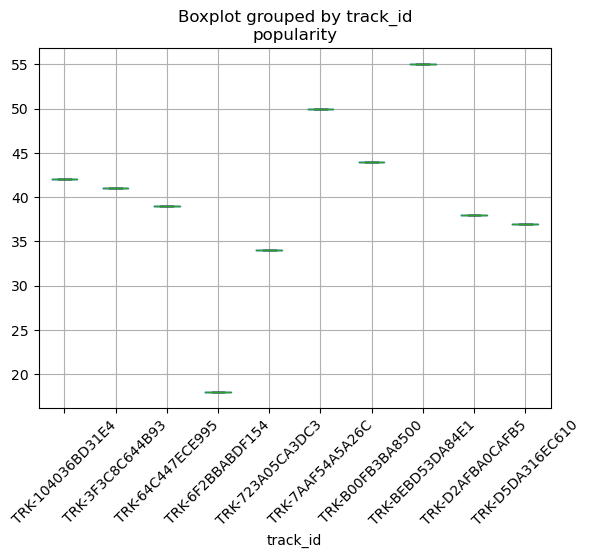

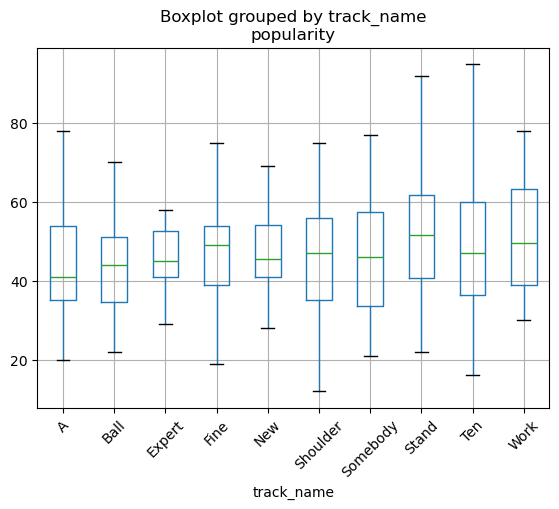

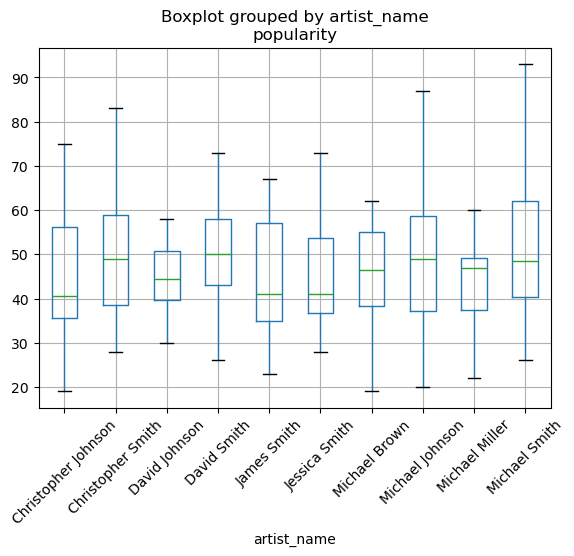

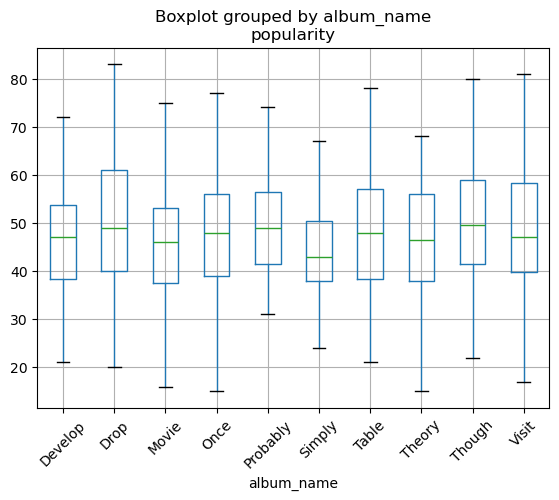

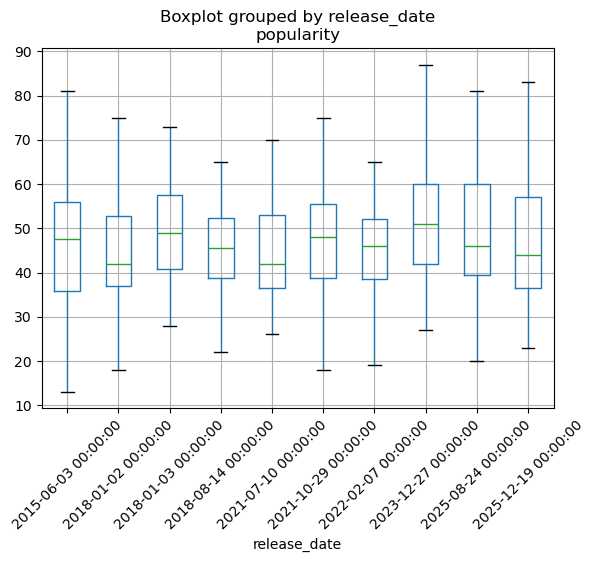

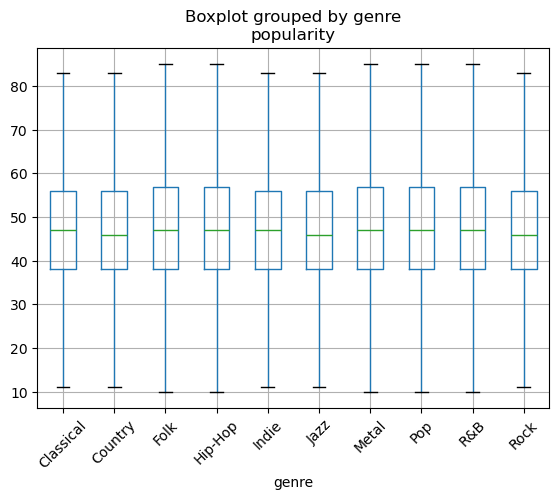

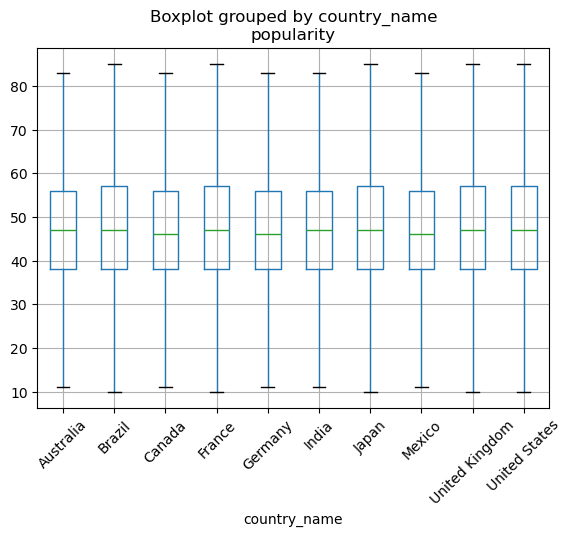

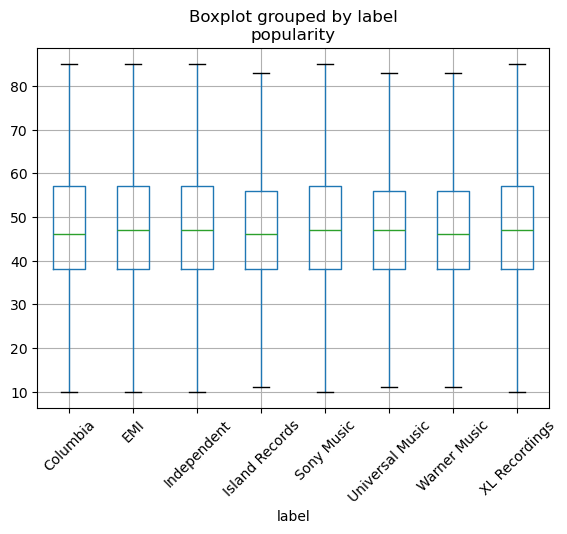

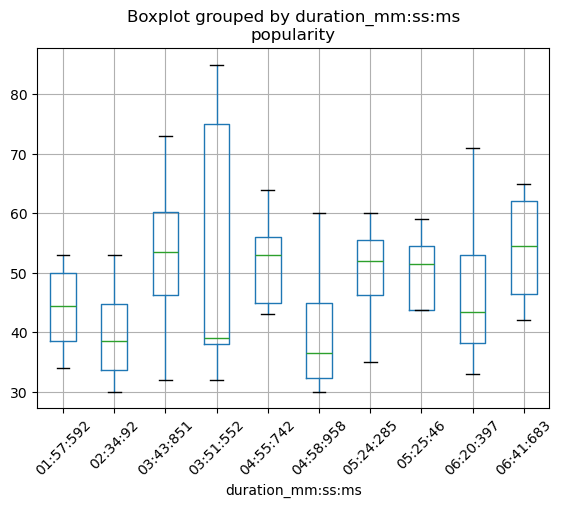

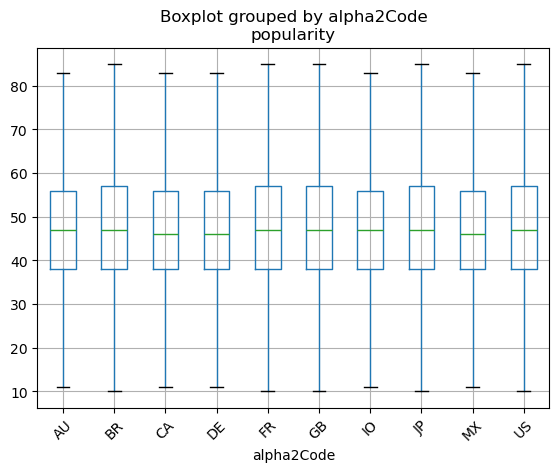

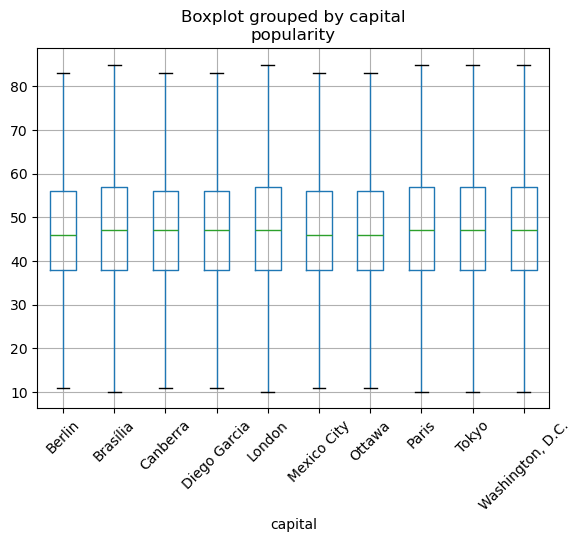

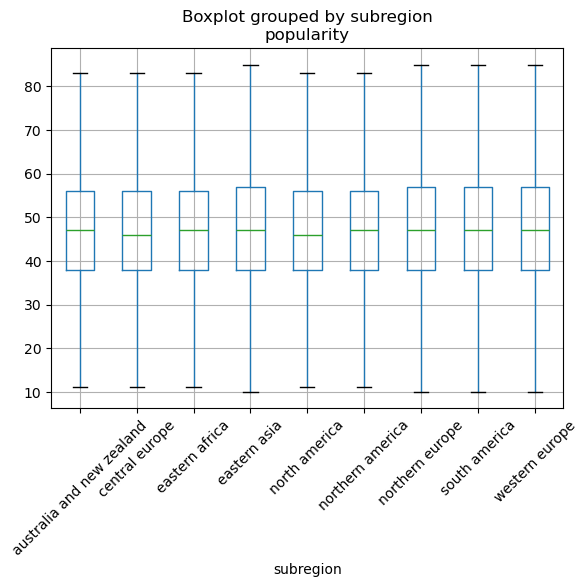

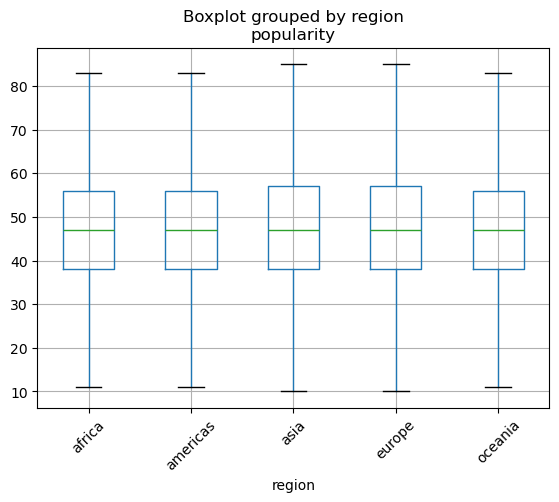

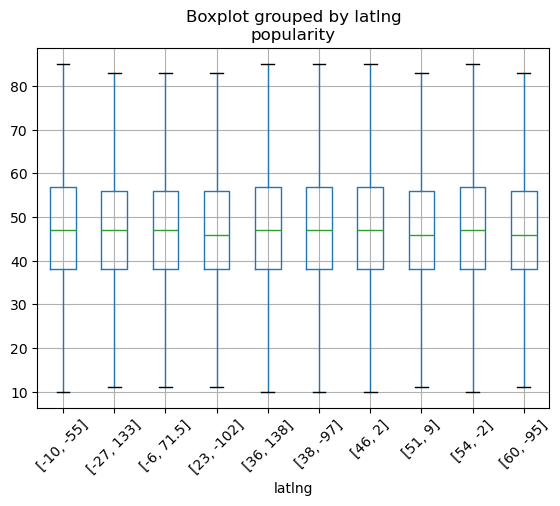

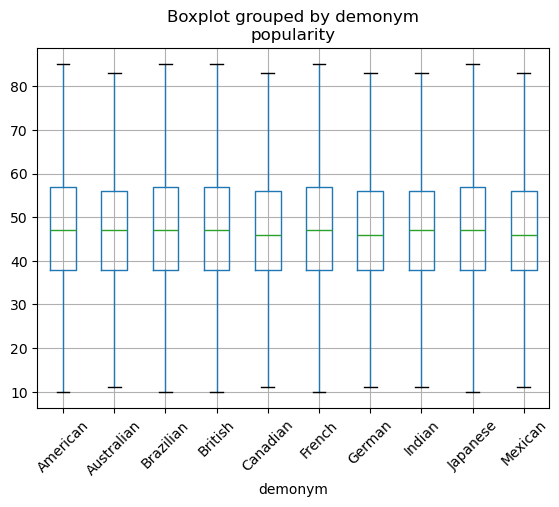

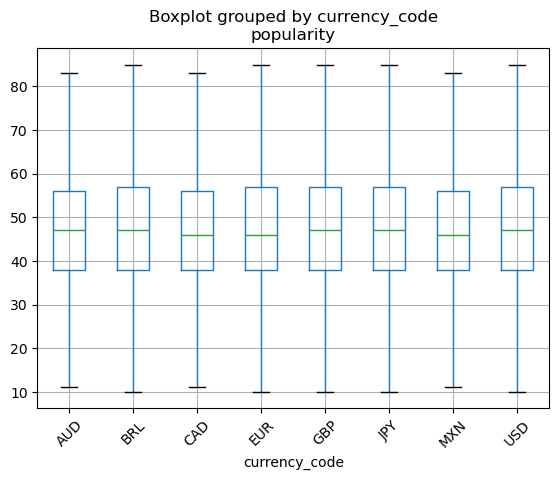

In [54]:
for col in multi_cat_cols:
    print(f"\nAnalyzing: {col}")

    top_categories = (
        combined_df[col]
        .value_counts()
        .head(10)
        .index
    )

    temp_df = combined_df[combined_df[col].isin(top_categories)]

    display(
        temp_df.groupby(col)["popularity"]
        .agg(["mean", "median", "count"])
        .sort_values("mean", ascending=False)
    )

    temp_df.boxplot(column="popularity", showfliers=False, by=col, rot=45)

## EDA Conclusion

During the Exploratory Data Analysis phase, both numerical and categorical features were examined to understand their distributions, relationships, and potential influence on track popularity. Initial distributional analysis revealed a diverse and well-balanced dataset across core audio features, while stream count exhibited strong right skew consistent with real-world listening behavior. Deeper feature-level exploration showed that popularity is not driven by a single dominant factor, but rather reflects a combination of artist-level, genre-level, temporal, and regional influences.

Some specific insights gathered from the EDA process are:
- Stream count correlates with popularity, but timing matters. Stream count showed the strongest relationship with popularity; however, further exploration revealed that release date plays a meaningful role. Songs that have been available longer naturally accumulate more streams, indicating that raw stream count is partially a function of exposure time rather than pure listener preference.

- Most artists and songs have limited representation. The majority of artists appear only once in the dataset, while a small number of artists contribute many tracks. This long-tail distribution suggests that artist-level reputation may matter, but the dataset is not dominated by a handful of artists.

- Popularity and maximum streams do not always align. While there are songs with both maximum stream counts and perfect popularity scores, many tracks with high streams do not receive a popularity score of 100. This indicates that Spotify’s popularity metric is influenced by factors beyond total streams alone.

- Genre, label, and region show patterns but not dominance. Genres and labels rank differently depending on whether popularity, total streams, or artist representation is considered. Region-level analysis showed Asia leading in both popularity and total streams, suggesting geographic concentration, but no categorical feature showed a singular controlling effect.

Correlation analysis across numeric and categorical features further supported this finding, indicating that popularity does not exhibit strong linear relationships with individual features. Instead, the results suggest that popularity is shaped by non-linear effects and interactions among multiple variables. Based on these findings, all features were retained for preprocessing and modeling to allow downstream models to capture complex relationships that are not apparent through univariate or linear analysis alone.